# Seasonal Agriculture Performance Analysis

### Major Data Analytics Project

**Student Name:** Deepanjali Thakur
**Internship Domain:** Data Science and Artificial Intelligence
**Project Domain:** Agriculture
**Project Theme:** Seasonal Agriculture Performance
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## Project Goal

Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

> **Important:** This is a Data Analytics project. No Machine Learning or dashboard development is required.

In [40]:
#Upload your dataset
from google.colab import files
uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (2).csv


In [41]:
#Step 2 — Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [42]:
#Step 3 — Load the dataset
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [43]:
#Understand the Dataset
print("Shape:", df.shape)
print(df.columns.tolist())
df.tail(5)

Shape: (4000, 28)
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [44]:
#Step 5 — Data types & non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [45]:
#Step 6 — Missing values
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [46]:
#Step 7 — Duplicate check
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [47]:
#Step 8 — Unique values in categorical columns
categorical_columns = ["State", "District", "Crop", "Season", "Irrigation_Method"]
for col in categorical_columns:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].unique())


State: 8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District: 10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop: 8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season: 3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method: 4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [48]:
#Clean the Data

#Step 9 — Handle missing values (with reasoning, don't just dump zeros)
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [49]:
#Confirm data types are correct after cleaning
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [50]:
#Step 11 — Summary stats
stats = df[numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]
stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


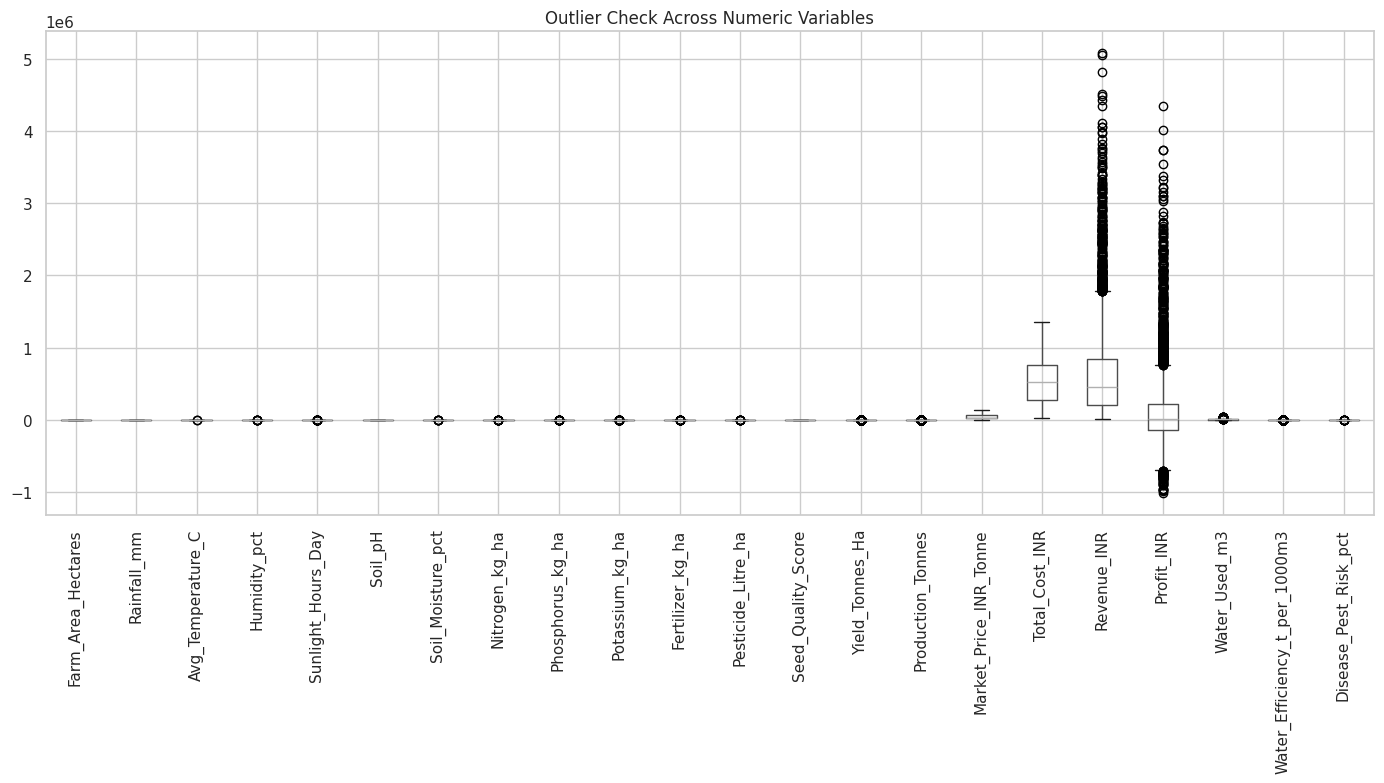

In [51]:
plt.figure(figsize=(14,8))
df[numeric_columns].boxplot(rot=90)
plt.title("Outlier Check Across Numeric Variables")
plt.tight_layout()
plt.show()

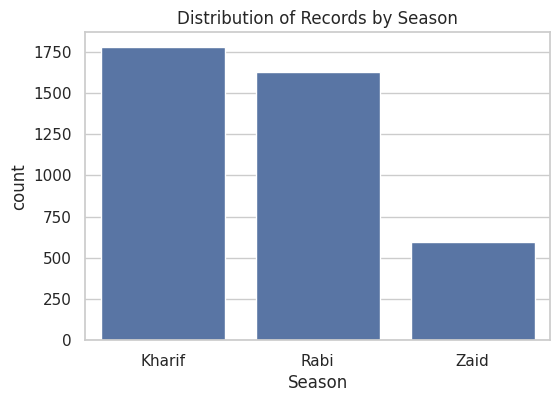

In [52]:
#Step 12 — Season distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Season", order=df["Season"].value_counts().index)
plt.title("Distribution of Records by Season")
plt.show()

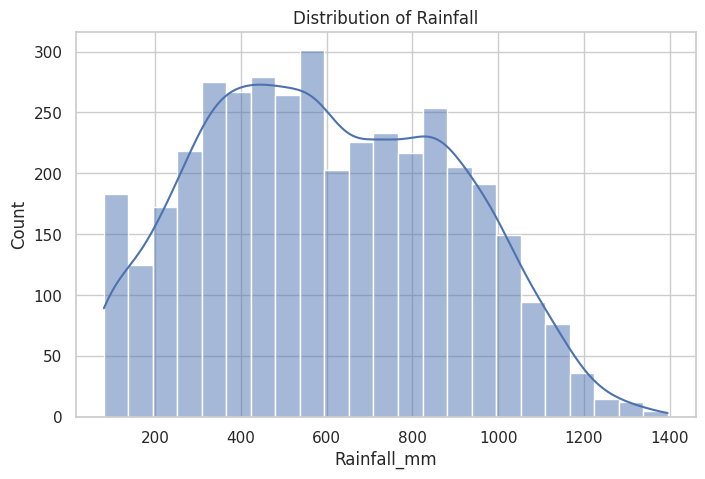

In [53]:
#Step 13 — Rainfall distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.show()

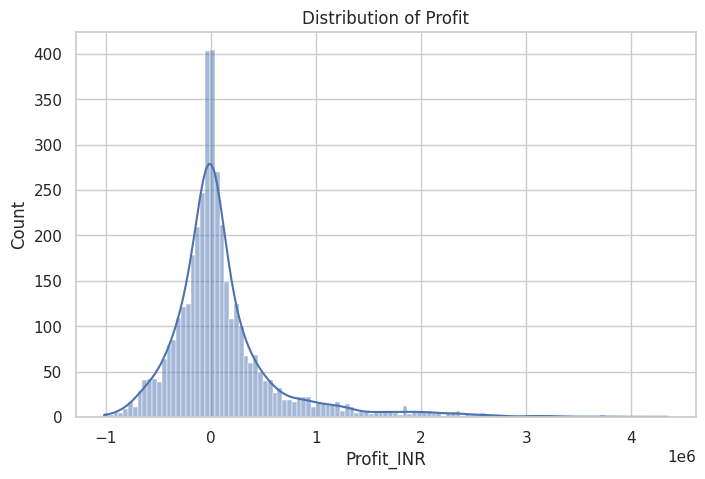

In [54]:
#Step 14 — Profit distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Profit")
plt.show()

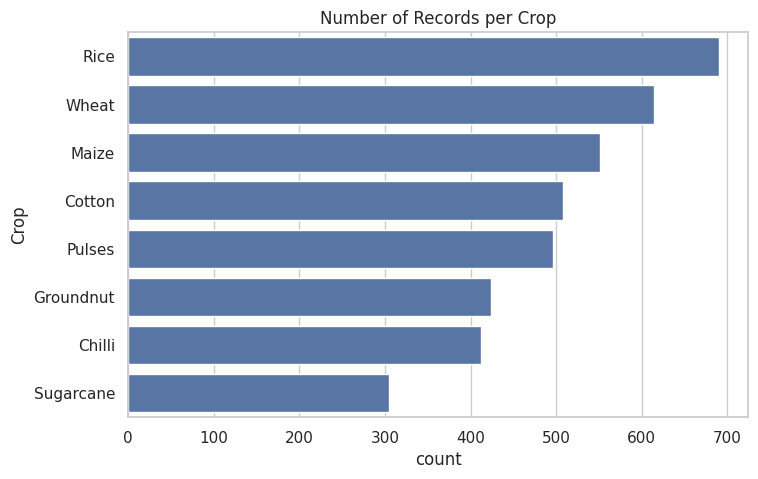

In [55]:
#Step 15 — Crop-wise record count
plt.figure(figsize=(8,5))
sns.countplot(data=df, y="Crop", order=df["Crop"].value_counts().index)
plt.title("Number of Records per Crop")
plt.show()

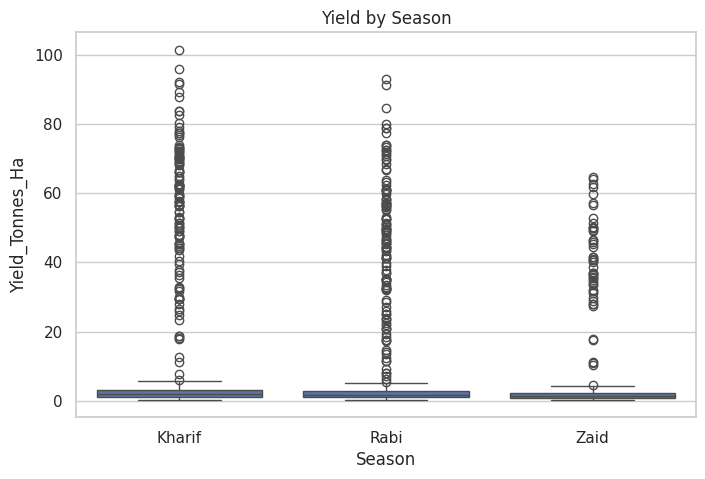

In [56]:
#Step 16 — Yield by Season (boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield by Season")
plt.show()

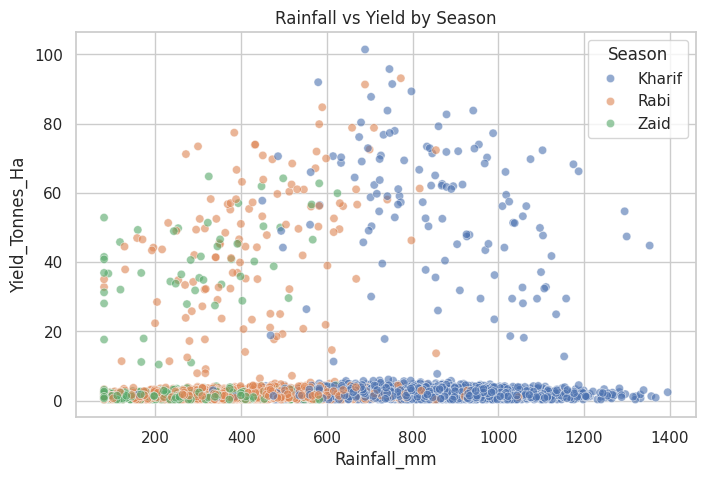

In [57]:
#Step 17 — Rainfall vs Yield (scatter)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", alpha=0.6)
plt.title("Rainfall vs Yield by Season")
plt.show()

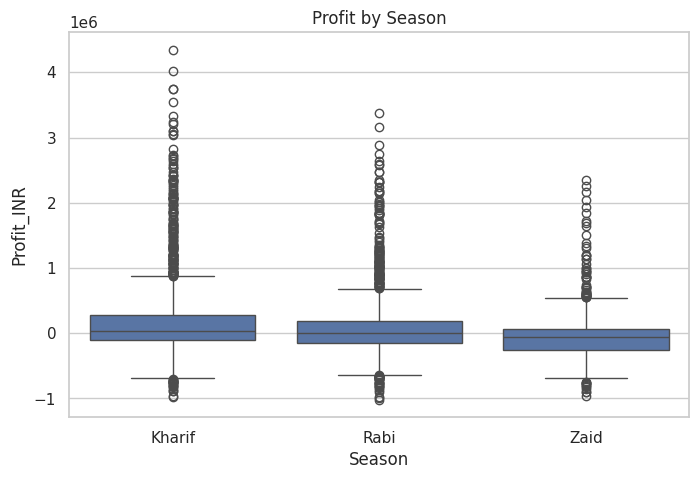

In [58]:
#Step 18 — Profit by Season
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Season", y="Profit_INR")
plt.title("Profit by Season")
plt.show()

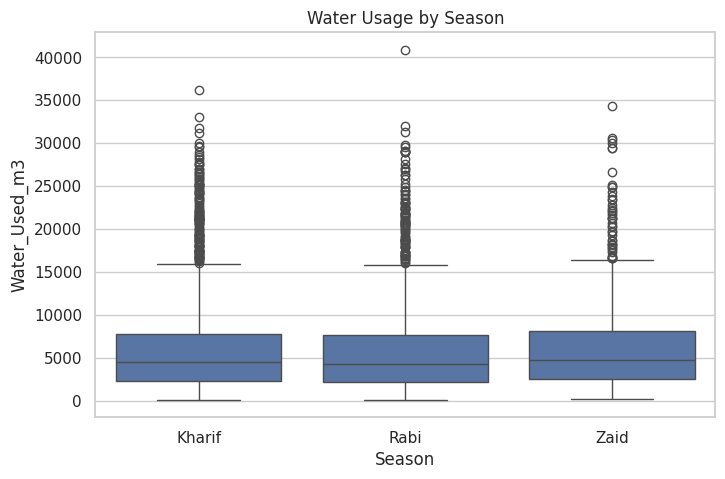

In [59]:
#Step 19 — Water usage by Season
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Season", y="Water_Used_m3")
plt.title("Water Usage by Season")
plt.show()

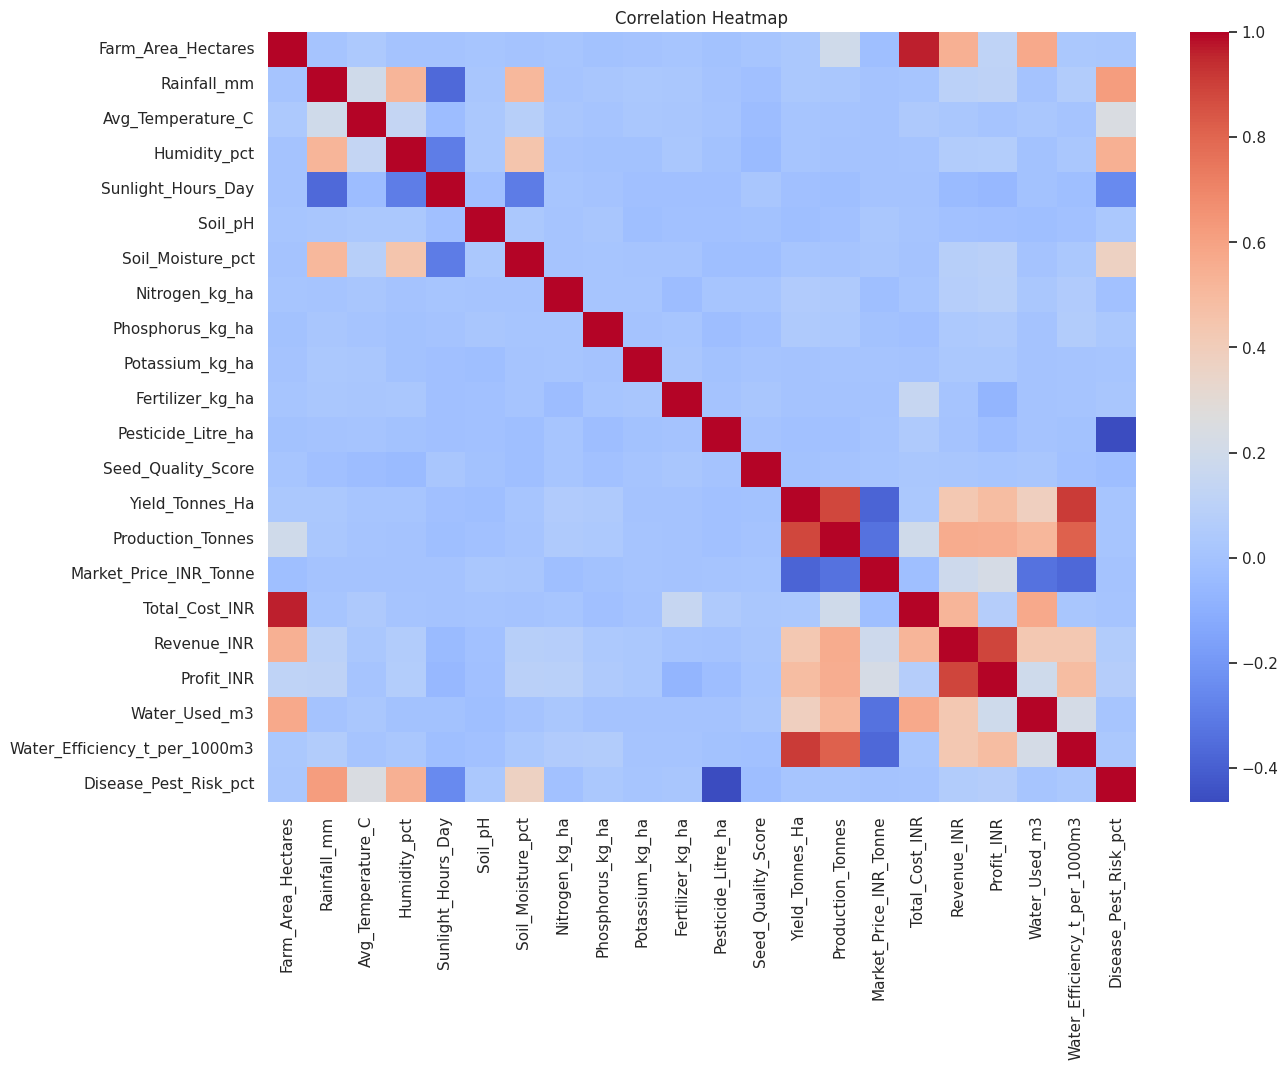

In [60]:
#Step 20 — Correlation heatmap
plt.figure(figsize=(14,10))
corr = df[numeric_columns].corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [61]:
#Step 21 — Top correlations with Yield
corr["Yield_Tonnes_Ha"].sort_values(ascending=False)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.00
Water_Efficiency_t_per_1000m3,0.91
Production_Tonnes,0.88
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Rainfall_mm,0.03
Total_Cost_INR,0.03


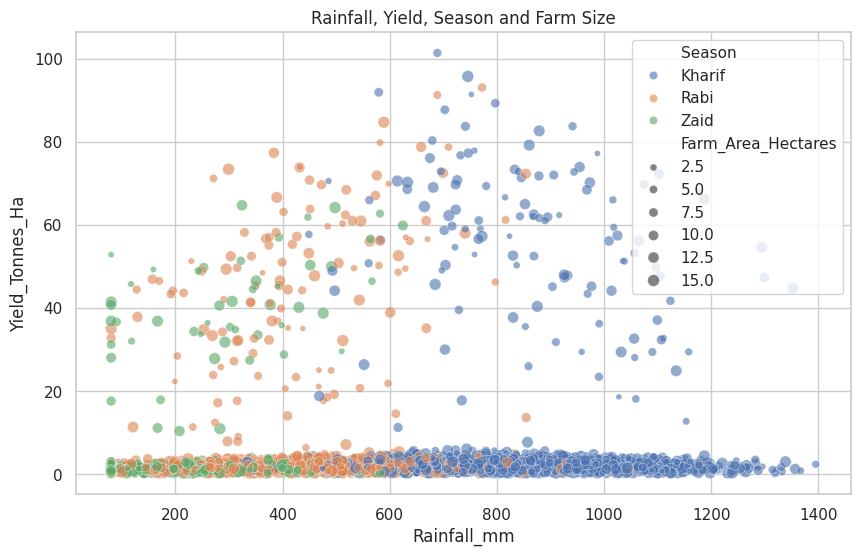

In [62]:
#Multivariate Analysis

#Step 22 — Yield vs Rainfall vs Season vs Crop
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", size="Farm_Area_Hectares", alpha=0.6)
plt.title("Rainfall, Yield, Season and Farm Size")
plt.show()

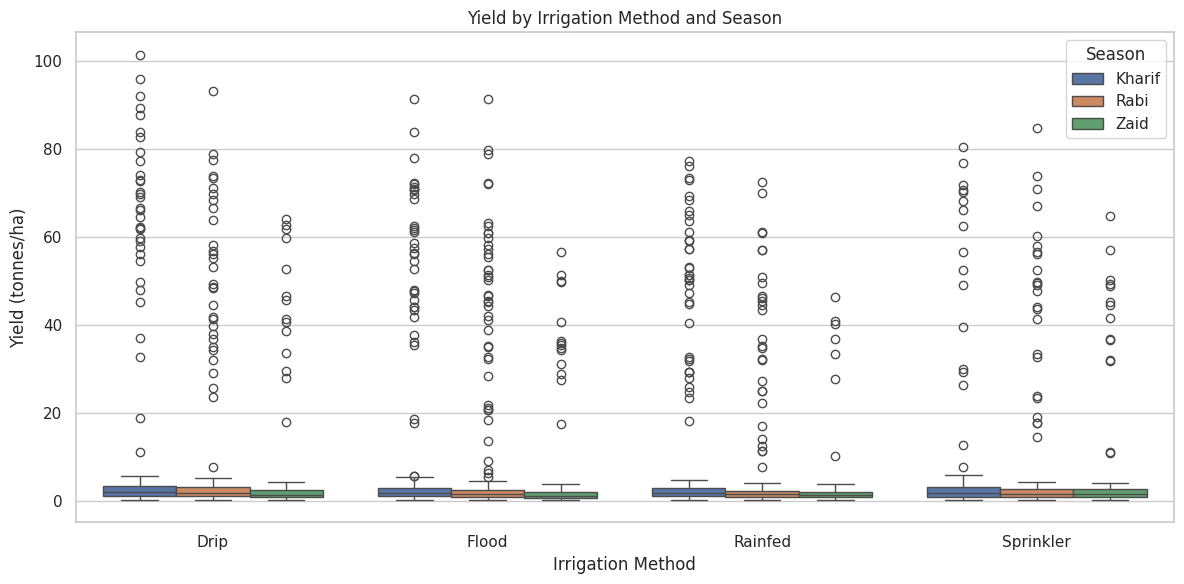

In [63]:
#Step 22b — Yield by Irrigation Method and Season
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

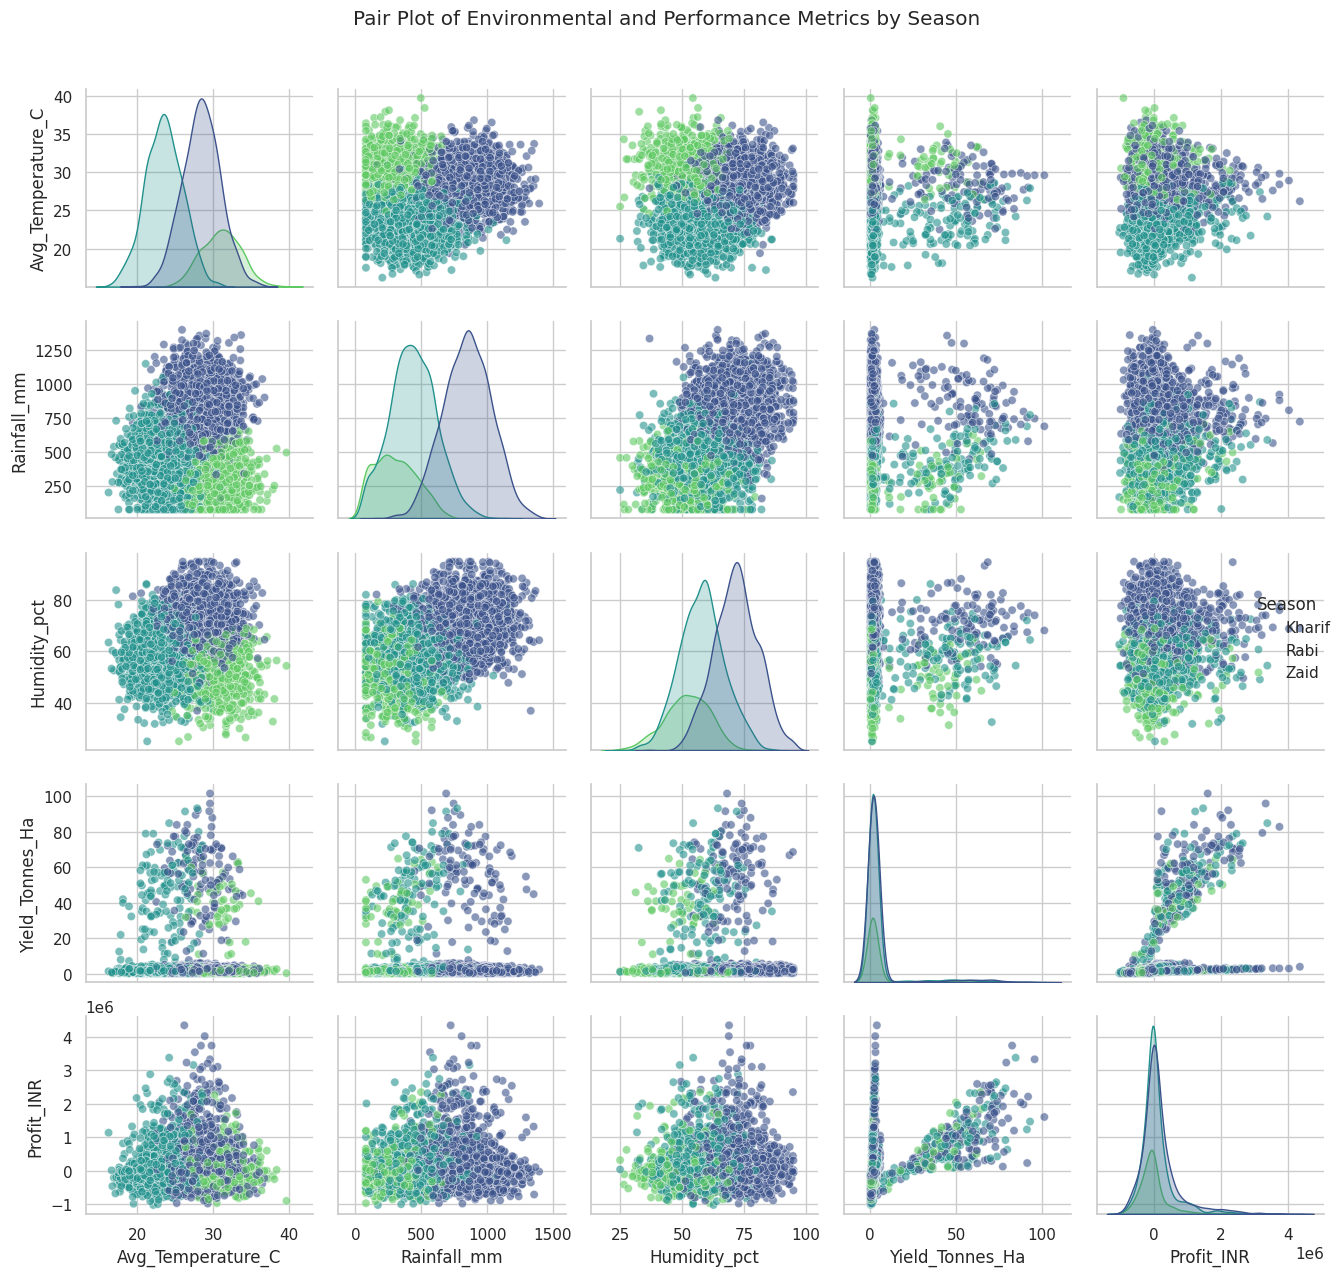

In [64]:
#Step 22c — Pair plot of environmental & performance metrics by Season
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']
sns.pairplot(df[selected_columns], hue='Season', palette='viridis', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y=1.02)
plt.tight_layout()
plt.show()

In [65]:
#Step 23 — Pivot table: avg yield by Season & Crop
pivot = df.pivot_table(values="Yield_Tonnes_Ha", index="Crop", columns="Season", aggfunc="mean")
pivot

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


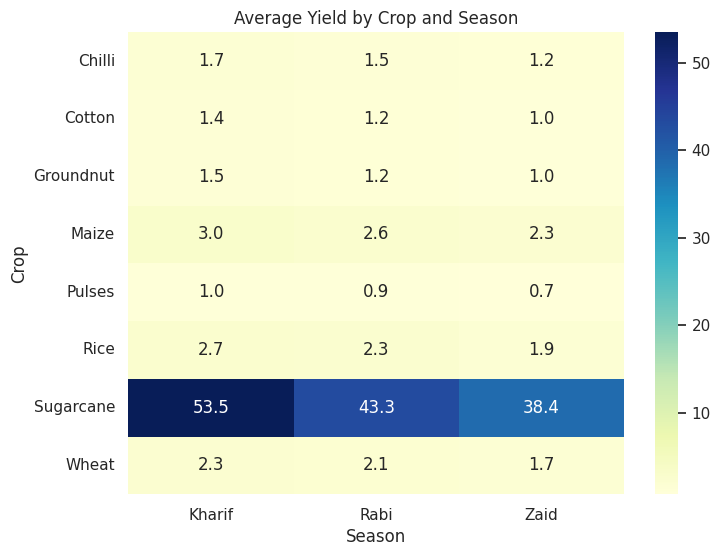

In [66]:
#Step 24 — Heatmap of that pivot
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Average Yield by Crop and Season")
plt.show()

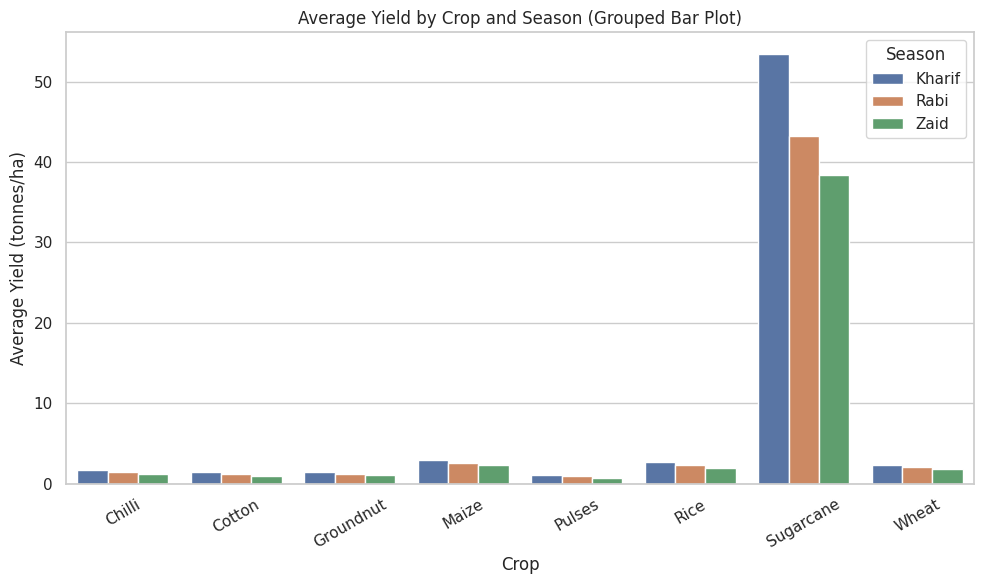

In [67]:
pivot_reset = pivot.reset_index().melt(id_vars="Crop", var_name="Season", value_name="Avg_Yield")

plt.figure(figsize=(10,6))
sns.barplot(data=pivot_reset, x="Crop", y="Avg_Yield", hue="Season")
plt.title("Average Yield by Crop and Season (Grouped Bar Plot)")
plt.ylabel("Average Yield (tonnes/ha)")
plt.xticks(rotation=30)
plt.legend(title="Season")
plt.tight_layout()
plt.show()

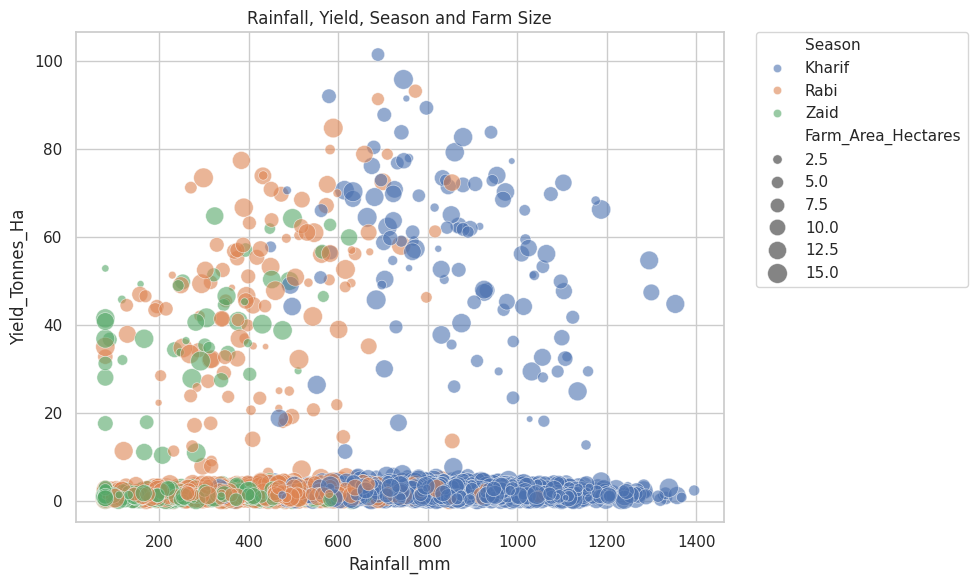

In [68]:
plt.figure(figsize=(10,6))
scatter = sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", size="Farm_Area_Hectares", sizes=(20,200), alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("Rainfall, Yield, Season and Farm Size")
plt.tight_layout()
plt.show()

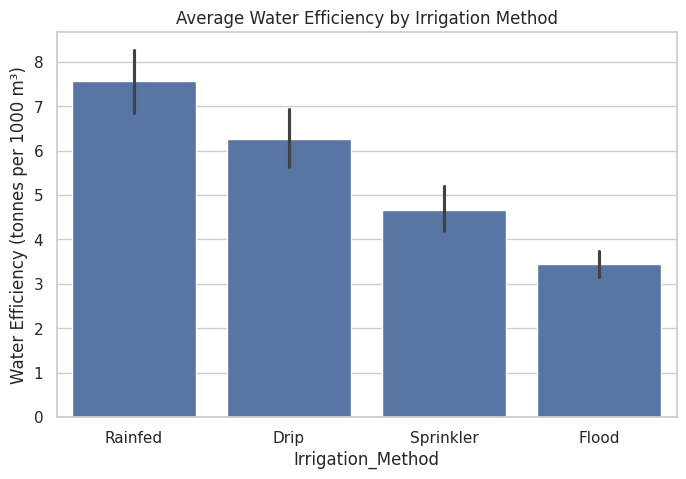

In [69]:
#Analysis 1: "Which irrigation method is actually the smartest choice — high yield or high efficiency?"
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Irrigation_Method", y="Water_Efficiency_t_per_1000m3",
            order=df.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean().sort_values(ascending=False).index)
plt.title("Average Water Efficiency by Irrigation Method")
plt.ylabel("Water Efficiency (tonnes per 1000 m³)")
plt.show()

Rainfed farms are the most water-efficient (7.56), even though Drip gives the highest yield (6.58). Interpretation: yield and efficiency don't always agree — a farm optimizing for water conservation might prefer Rainfed/Drip over Flood irrigation, which is both low-yield AND low-efficiency.

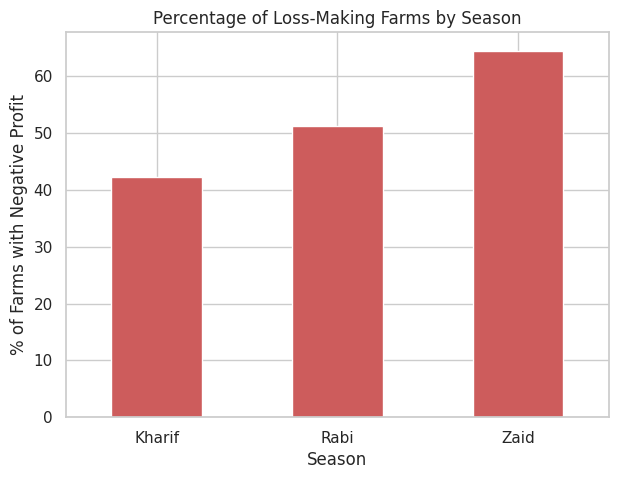

Season
Kharif   42.20
Rabi     51.10
Zaid     64.50
Name: Profit_INR, dtype: float64


In [70]:
#Analysis 2: "Is farm profitability actually collapsing across seasons, or just yield?"
loss_pct = df.groupby("Season")["Profit_INR"].apply(lambda x: (x < 0).mean() * 100)

plt.figure(figsize=(7,5))
loss_pct.plot(kind="bar", color="indianred")
plt.title("Percentage of Loss-Making Farms by Season")
plt.ylabel("% of Farms with Negative Profit")
plt.xticks(rotation=0)
plt.show()

print(loss_pct.round(1))

42% of Kharif farms lose money, rising to 51% in Rabi and 65% in Zaid. This is a much sharper and more useful insight than just "profit is lower in Zaid" — it shows most Zaid farms are actively unprofitable, not just less profitable.

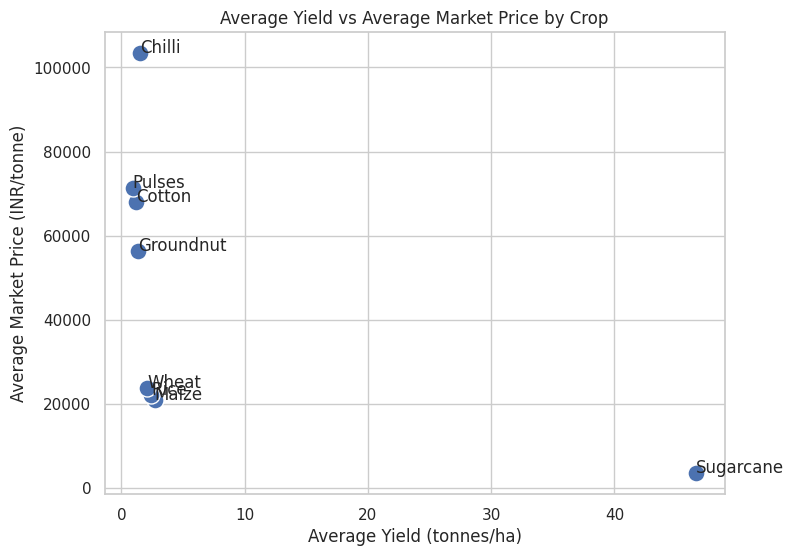

In [71]:
#Analysis 3: "Does higher yield actually mean higher market price, or the opposite?"
crop_summary = df.groupby("Crop").agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Price=("Market_Price_INR_Tonne", "mean")
).sort_values("Avg_Yield", ascending=False)

plt.figure(figsize=(8,6))
sns.scatterplot(data=crop_summary, x="Avg_Yield", y="Avg_Price", s=150)
for crop in crop_summary.index:
    plt.text(crop_summary.loc[crop, "Avg_Yield"], crop_summary.loc[crop, "Avg_Price"], crop)
plt.title("Average Yield vs Average Market Price by Crop")
plt.xlabel("Average Yield (tonnes/ha)")
plt.ylabel("Average Market Price (INR/tonne)")
plt.show()

high-yield crops (Sugarcane) sell at low per-tonne prices, while low-yield crops (Chilli, Cotton) sell at much higher prices — an inverse relationship. This matches the -0.38 correlation we found earlier between yield and market price.

## 8. Key Insights

1. **Kharif dominates the dataset** — 1,779 records (44.5%), vs Rabi (1,627, 40.7%) and Zaid (594, 14.9%). Seasonal comparisons for Zaid rest on a comparatively smaller sample.

2. **Yield is highest in Kharif and lowest in Zaid** — mean yield falls from 5.63 t/ha (Kharif) → 5.04 (Rabi) → 4.64 (Zaid), tracking the drop in rainfall across the same seasons (849mm → 438mm → 305mm mean).

3. **Profitability collapses far faster than yield does** — mean profit falls from ₹1.79L (Kharif) to ₹0.88L (Rabi) to a net loss of ₹-24,800 (Zaid). Profit is much more season-sensitive than yield.

4. **Most farms are unprofitable, and it worsens by season** — 42.2% of Kharif farms report a loss, rising to 51.1% in Rabi and 64.5% in Zaid.

5. **Water usage does not track rainfall** — despite Zaid having the least rainfall, it has the highest mean water usage (6,420 m³) vs Kharif (6,102) and Rabi (5,847), suggesting farmers compensate for low rainfall with irrigation, at added cost.

6. **Rainfall barely correlates with yield directly** (r = 0.03) — likely because irrigation substitutes for natural rainfall, decoupling yield from it (consistent with Insight 5).

7. **Yield is driven mainly by water efficiency and production scale, not environmental inputs** — Water_Efficiency (r = 0.91) and Production_Tonnes (r = 0.88) dominate, while Soil pH, Sunlight, Nitrogen and Fertilizer all show near-zero correlation (< 0.05).

8. **Market price is inversely related to yield** (r = -0.38) — high-yield crops sell at lower per-tonne prices, and low-yield crops command higher prices, a supply/price trade-off confirmed in Analysis 3.

9. **Sugarcane is a major outlier** — its yield (40–53 t/ha) is 15–20x any other crop, and it is also the most profitable crop (₹8.17L average profit), which can distort "typical" crop-level averages.

10. **Irrigation method involves a trade-off, not a single best option** — Drip irrigation gives the highest yield (6.58 t/ha) but Rainfed farms are the most water-efficient (7.56 t/1000m³), so the "best" method depends on whether yield or water conservation is prioritized (confirmed in Analysis 1).

## 9. Evidence-Based Recommendations

1. **Prioritize support for Zaid season farming** — with 64.5% of Zaid farms operating at a loss, this season needs targeted intervention: subsidized irrigation access, crop insurance, or minimum price guarantees to reduce farmer risk.

2. **Shift focus from water volume to water efficiency** — since Water_Efficiency correlates far more strongly with yield (r = 0.91) than raw rainfall does (r = 0.03), training farmers in efficient irrigation practices (like drip systems) would likely improve outcomes more than simply increasing water supply.

3. **Encourage Rainfed or Drip irrigation over Flood irrigation** — Flood irrigation underperforms on both yield and water efficiency, making it the least favorable method in this dataset; reallocating resources toward Drip (highest yield) or Rainfed (highest efficiency) depending on the goal would improve outcomes.

4. **Reconsider over-reliance on Sugarcane for profitability metrics** — since Sugarcane's scale skews crop-level averages, policy or planning decisions should evaluate crops both with and without Sugarcane included, to avoid over- or under-estimating the performance of other crops.

5. **Support crop diversification strategies** — because market price and yield are inversely related, farmers relying solely on high-yield crops (e.g. Sugarcane) may face price compression, while diversifying into lower-yield but higher-price crops (e.g. Chilli, Cotton) could stabilize income.

## 10. Limitations

1. **Missing value imputation** — missing values in Rainfall_mm, Soil_Moisture_pct, and Yield_Tonnes_Ha were filled using the median, which can slightly understate the true variability in the original data.

2. **Sugarcane distorts crop-level averages** — its yield and profit figures are 15–20x higher than any other crop, which can make overall "average crop performance" figures misleading if Sugarcane is not considered separately.

3. **Correlation does not imply causation** — relationships identified (e.g. between water efficiency and yield, or market price and yield) describe association in this dataset, not proven cause-and-effect.

4. **Uneven sample sizes across seasons** — Zaid season has considerably fewer records (594) than Kharif (1,779) or Rabi (1,627), so seasonal comparisons involving Zaid are based on a smaller, potentially less representative sample.

5. **Cross-sectional data, not time-series** — the dataset captures a snapshot across farms and seasons rather than tracking the same farms over multiple years, so trends over time cannot be confirmed from this data alone.

## 11. Conclusion

This analysis of 4,000 farm-level records across three seasons (Kharif, Rabi and Zaid) shows that agricultural performance is strongly season-dependent, but not in the way rainfall alone would suggest. While yield declines only moderately from Kharif to Zaid, profitability declines far more sharply, with the majority of Zaid-season farms operating at a loss. Water usage does not scale down with the lower rainfall in Zaid, indicating that farmers are compensating through irrigation, often without a corresponding improvement in returns.

The strongest drivers of yield in this dataset are water efficiency and production scale, not environmental factors like soil quality, sunlight, or fertilizer use, while market price moves inversely with yield, exposing high-yield crops to price compression. Irrigation method choice also involves a genuine trade-off between maximizing yield (Drip) and maximizing water efficiency (Rainfed), rather than a single universally superior option.

Overall, the findings suggest that seasonal agricultural planning should focus less on maximizing yield alone and more on improving water-use efficiency, supporting crop diversification, and providing targeted financial protection for higher-risk seasons like Zaid. Future analysis incorporating multi-year, time-series data would help confirm whether these seasonal patterns are consistent trends or specific to the period captured in this dataset.